# Quickstart: Fit a Galaxy in Under a Minute

This notebook shows the complete diffsed workflow: create a model galaxy, fit it with MAP optimization, and inspect the results. For theory, see Tutorial 1.

## Installation

```bash
pip install -e .  # from the diffsed repo
# Download SSP templates:
curl -O https://halos.as.arizona.edu/suchethacooray/dsps_ssp/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5
# Optional (for posterior sampling):
pip install blackjax optax
```

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "../src")
from diffsed.utils.devices import setup_jax
setup_jax()

import jax, jax.numpy as jnp, matplotlib.pyplot as plt
from diffsed.models.sps.dsps_wrapper import load_ssp_data
from diffsed.forward_model import ForwardModel, ModelConfig, generate_mock
from diffsed.inference.map_optimizer import fit_map

# Load SSP templates (with nebular emission)
ssp = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# SDSS-like filters (simple top-hats)
bands = {"u": 3551, "g": 4686, "r": 6166, "i": 7480, "z": 8932}
fw = [jnp.linspace(c - 100, c + 100, 50) for c in bands.values()]
ft = [jnp.ones(50) for _ in bands]

## Create a Mock Galaxy

In [2]:
config = ModelConfig(n_grid=256, redshift=0.1)
model = ForwardModel(ssp, config=config, filter_waves=fw, filter_trans=ft)

# True parameters (BAGPIPES-style dict)
true_params = {
    "xi": jax.random.normal(jax.random.PRNGKey(42), shape=(config.n_grid,)),
    "sigma_ps": 1.0,     # PSD amplitude
    "tau_ps": 100e6,     # PSD timescale (yr)
    "alpha": 2.0,        # falling slope
    "beta": 1.0,         # rising slope
    "tau_sfh": 3e9,      # SFH turnover (yr)
    "sfr_norm": 10.0,    # peak SFR (M${_{\odot}}$/yr)
    "log_z": -0.3,       # log(Z/Z${_{\odot}}$)
    "tau_v1": 1.0,       # birth-cloud dust
    "tau_v2": 0.3,       # diffuse dust
    "dust_n": -0.7,      # dust power-law index
}

mock = generate_mock(model, true_params, key=jax.random.PRNGKey(0), snr=20.0)
print(f"Mock galaxy: {len(bands)}-band photometry, SNR=20")

W0313 17:57:04.396687 2281225 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Mock galaxy: 5-band photometry, SNR=20


## Fit with MAP Optimization

In [3]:
result = fit_map(model, mock["flux_obs"], mock["noise"], n_steps=1500, verbose=False)
print(f"Fit complete in {result.wall_time_s:.1f} seconds")

Fit complete in 3.2 seconds


## Results

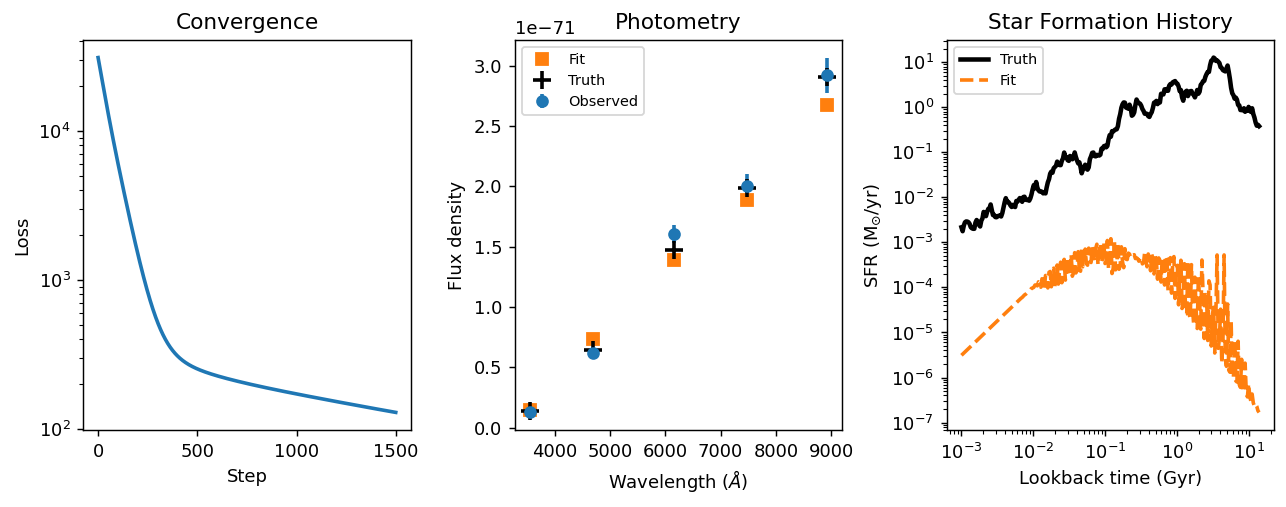

In [4]:
from diffsed.models.sfh.gp_sfh import gp_from_xi, compute_sqrt_power_drw
from diffsed.models.sfh.psd_models import drw_variance
from diffsed.models.sfh.mean_sfh import double_powerlaw
from diffsed.utils.grid import log_age_to_age_yr

def compute_sfh(params, model):
    """Reconstruct the SFH from parameter dict."""
    sqrt_power = model.compute_sqrt_power(params["sigma_ps"], params["tau_ps"])
    gp_x = gp_from_xi(params["xi"], sqrt_power, model.config.n_grid)
    k0_half = drw_variance(params["sigma_ps"]) / 2.0
    sfr_mean = double_powerlaw(
        model.age_yr, alpha=params["alpha"], beta=params["beta"],
        tau=params["tau_sfh"], norm=params["sfr_norm"],
    )
    return sfr_mean * jnp.exp(gp_x - k0_half)

sfh_true = compute_sfh(true_params, model)
sfh_fit  = compute_sfh(result.params, model)
lookback_gyr = model.age_yr / 1e9

flux_fit = model.predict_photometry(result.params)
wave_eff = jnp.array(list(bands.values()))

fig, axes = plt.subplots(1, 3, figsize=(10, 4), dpi=130)

# Left: loss convergence
axes[0].plot(jnp.arange(len(result.loss_history)), result.loss_history, lw=2)
axes[0].set_xlabel(r"Step")
axes[0].set_ylabel(r"Loss")
axes[0].set_title(r"Convergence")
axes[0].set_yscale("log")

# Middle: photometry
axes[1].errorbar(wave_eff, mock["flux_obs"], yerr=mock["noise"],
                 fmt="o", color="C0", label=r"Observed", ms=6, lw=2)
axes[1].plot(wave_eff, flux_fit, "s", color="C1", ms=7, label=r"Fit")
axes[1].plot(wave_eff, mock["flux_true"], "+", color="k", ms=10, mew=2, label=r"Truth")
axes[1].set_xlabel(r"Wavelength ($\AA$)")
axes[1].set_ylabel(r"Flux density")
axes[1].set_title(r"Photometry")
axes[1].legend(fontsize=8)

# Right: SFH
axes[2].plot(lookback_gyr, sfh_true, lw=2.5, color="k", label=r"Truth")
axes[2].plot(lookback_gyr, sfh_fit, lw=2, color="C1", ls="--", label=r"Fit")
axes[2].set_xlabel(r"Lookback time (Gyr)")
axes[2].set_ylabel(r"SFR (M$_{\odot}$/yr)")
axes[2].set_title(r"Star Formation History")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig("figures/00_quickstart_results.png", bbox_inches="tight")
plt.show()

## Parameter Recovery

In [5]:
param_names = [
    "sigma_ps", "tau_ps", "alpha", "beta",
    "tau_sfh", "sfr_norm", "log_z", "tau_v1", "tau_v2", "dust_n",
]
print(f"{'Parameter':<12} {'True':>12} {'Fitted':>12}")
print("-" * 38)
for name in param_names:
    t = float(true_params[name])
    f = float(result.params[name])
    print(f"{name:<12} {t:>12.4g} {f:>12.4g}")

Parameter            True       Fitted
--------------------------------------
sigma_ps                1        2.598
tau_ps              1e+08        1e+06
alpha                   2        2.021
beta                    1        1.529
tau_sfh             3e+09        1e+08
sfr_norm               10      0.01928
log_z                -0.3      -0.8643
tau_v1                  1        1.944
tau_v2                0.3        1.458
dust_n               -0.7      -0.7831


## What's Next

- **Tutorial 1**: The PSD -> GP -> SFH model in depth
- **Tutorial 2**: Dust, SSPs, and the full forward model
- **Tutorial 3**: Generating mock galaxies at different redshifts
- **Tutorial 4**: Fitting with photometry, spectroscopy, and joint
- **Tutorial 5**: Inference comparison -- MAP vs NUTS vs geoVI